In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, log_loss

# 1. Load data
df = pd.read_csv(r"C:\Users\tatha\Downloads\retail_customer_churn_100k (1).csv")

# Drop customer_id and the leaky 'churn_risk' target
X = df.drop(columns=['customer_id', 'churn_flag', 'churn_risk'])
y = df['churn_flag']

# Identify numerical and categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# 2. (a) Standardize numerical columns and encode categoricals
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ])

X_processed = preprocessor.fit_transform(X)

# Get feature names for mapping coefficients later
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)
feature_names = list(num_cols) + list(cat_feature_names)

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

# 3. (b) Perform Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# Predictions
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]

# 4. (c) Evaluate Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
sensitivity = recall_score(y_test, y_pred) # Also known as Recall or True Positive Rate

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp) # True Negative Rate
f1 = f1_score(y_test, y_pred)

# Note: Standard R-Squared doesn't apply to Logistic Regression. 
# We use McFadden's Pseudo R-Squared instead.
p_null = y_train.mean()
ll_null = np.sum(y_test * np.log(p_null) + (1 - y_test) * np.log(1 - p_null))
ll_model = -log_loss(y_test, y_prob, normalize=False)
pseudo_r2 = 1 - (ll_model / ll_null)

# Print Results
print("METRICS:")
print(f"Accuracy:    {accuracy:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score:    {f1:.4f}")
print(f"Pseudo R-Sq: {pseudo_r2:.4f} (McFadden's)")

print("\nCOEFFICIENTS:")
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': lr.coef_[0]})
print(coef_df.sort_values(by='Coefficient', ascending=False).to_string(index=False))
print(f"\nIntercept: {lr.intercept_[0]:.4f}")

METRICS:
Accuracy:    0.9450
Precision:   0.9400
Sensitivity: 0.9410
Specificity: 0.9484
F1-Score:    0.9405
Pseudo R-Sq: 0.8210 (McFadden's)

COEFFICIENTS:
                     Feature  Coefficient
                recency_days     7.453758
       cart_abandonment_rate     2.198171
             email_open_rate     0.727251
              website_visits     0.067872
             age_group_25-34     0.067632
    preferred_channel_Online     0.043940
        customer_segment_New     0.020618
               age_group_55+     0.018852
             avg_order_value     0.007817
         discount_usage_rate     0.007540
                gender_Other    -0.003147
             age_group_45-54    -0.010712
        customer_segment_VIP    -0.019784
                 gender_Male    -0.032729
             age_group_35-44    -0.032870
preferred_channel_Mobile App    -0.035802
                 region_East    -0.035806
                region_North    -0.053381
  customer_segment_Returning    -0.066740
   

In [12]:
import pandas as pd
import urllib
from sqlalchemy import create_engine

# 1. Load the raw data
df = pd.read_csv(r"C:\Users\tatha\Downloads\retail_customer_churn_100k (1).csv")

# Drop the leaky column right away
df = df.drop(columns=['churn_risk'])

# ---------------------------------------------------------
# 2. BUILD DIMENSION TABLES
# ---------------------------------------------------------

# Create Dim_Demographics
dim_demographics = df[['age_group', 'gender', 'region']].drop_duplicates().reset_index(drop=True)
dim_demographics.insert(0, 'demographic_id', dim_demographics.index + 1) # Create Primary Key

# Create Dim_Segment
dim_segment = df[['customer_segment', 'preferred_channel']].drop_duplicates().reset_index(drop=True)
dim_segment.insert(0, 'segment_id', dim_segment.index + 1) # Create Primary Key

# ---------------------------------------------------------
# 3. BUILD FACT TABLE (Map Foreign Keys)
# ---------------------------------------------------------

# Merge Demographics ID back to main dataframe
df = df.merge(dim_demographics, on=['age_group', 'gender', 'region'], how='left')

# Merge Segment ID back to main dataframe
df = df.merge(dim_segment, on=['customer_segment', 'preferred_channel'], how='left')

# Select only the IDs and numerical columns for the Fact Table
fact_columns = [
    'customer_id', 'demographic_id', 'segment_id', 
    'purchase_frequency', 'avg_order_value', 'total_spent', 
    'recency_days', 'website_visits', 'discount_usage_rate', 
    'email_open_rate', 'cart_abandonment_rate', 'loyalty_score', 
    'engagement_score', 'churn_flag'
]
fact_customer_analytics = df[fact_columns]

# ---------------------------------------------------------
# 4. SEND TO SQL SERVER (SSMS)
# ---------------------------------------------------------

# Define SQL Server credentials using Windows Authentication
server = r'TATHAGATA\SQLEXPRESS'
database = 'PRACTICEDB'

# Create the connection string
params = urllib.parse.quote_plus(
    f'DRIVER={{ODBC Driver 17 for SQL Server}};'
    f'SERVER={server};'
    f'DATABASE={database};'
    f'Trusted_Connection=yes;'
)

# Initialize SQLAlchemy Engine
engine = create_engine(f'mssql+pyodbc:///?odbc_connect={params}')

print("Connecting to SSMS and pushing tables...")

# Push Dim_Demographics
dim_demographics.to_sql('Dim_Demographics', con=engine, if_exists='replace', index=False)
print("- Dim_Demographics loaded successfully.")

# Push Dim_Segment
dim_segment.to_sql('Dim_Segment', con=engine, if_exists='replace', index=False)
print("- Dim_Segment loaded successfully.")

# Push Fact_Customer_Analytics
fact_customer_analytics.to_sql('Fact_Customer_Analytics', con=engine, if_exists='replace', index=False)
print("- Fact_Customer_Analytics loaded successfully.")

print("\nStar Schema Architecture successfully deployed to PRACTICEDB!")

Connecting to SSMS and pushing tables...


e:\VS Code\.venv\Lib\site-packages\pandas\io\sql.py:1648: SAWarning: Unrecognized server version info '17.0.1105.2'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


- Dim_Demographics loaded successfully.
- Dim_Segment loaded successfully.
- Fact_Customer_Analytics loaded successfully.

Star Schema Architecture successfully deployed to PRACTICEDB!


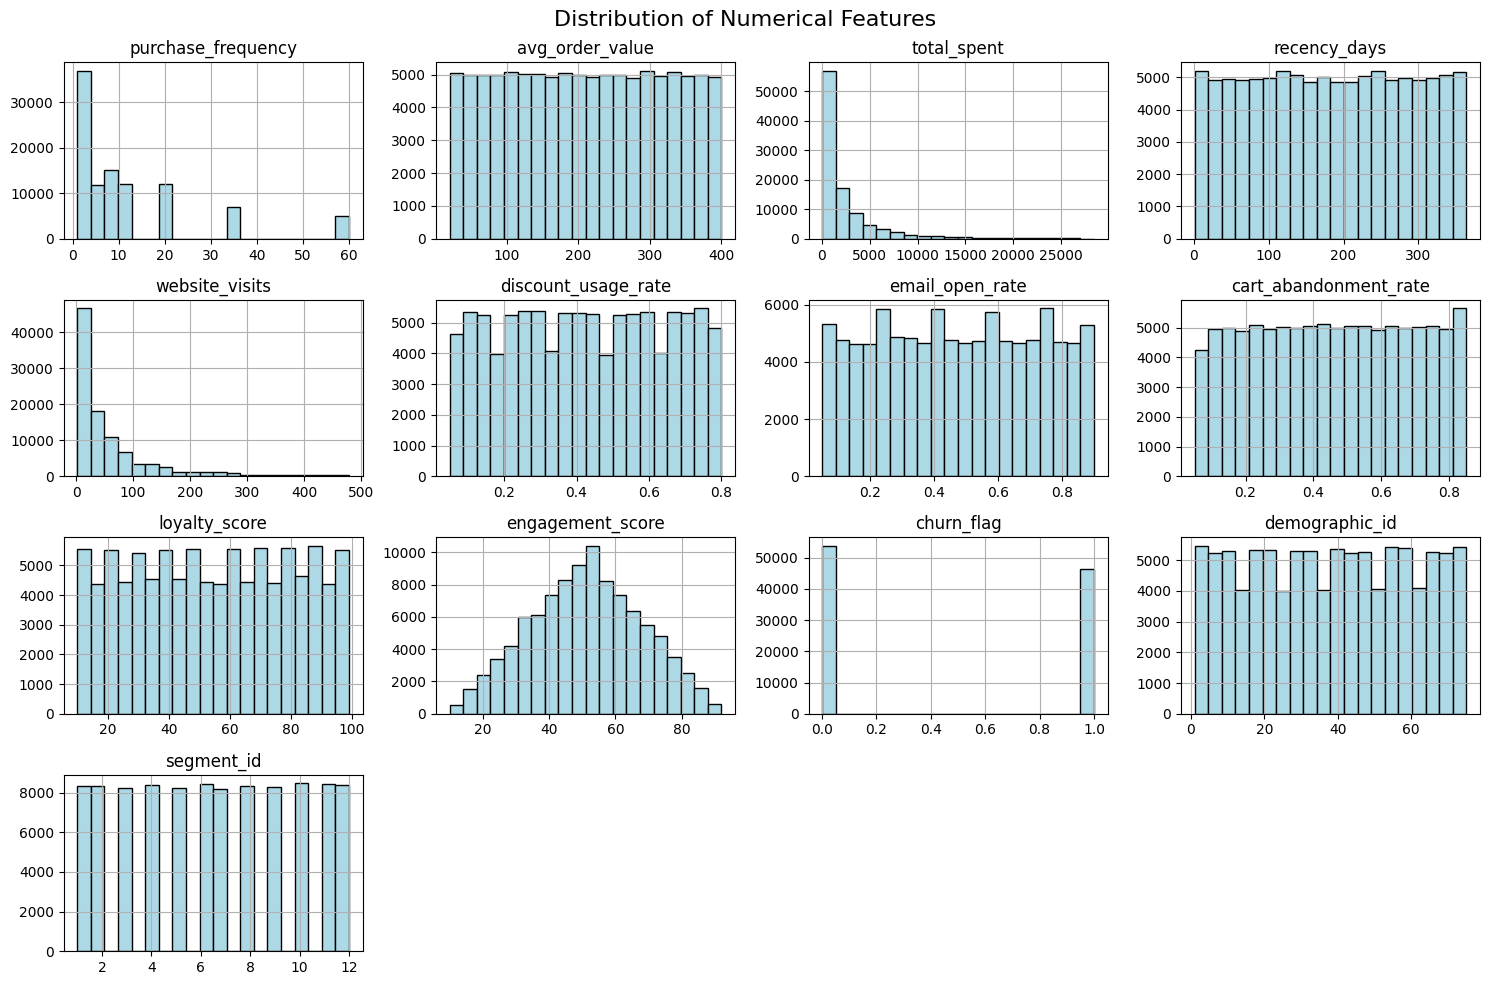

In [19]:
# Plot a histogram of all the numerical features to understand their distributions
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols].hist(figsize=(15, 10), bins=20, color='lightblue', edgecolor='black')
plt.suptitle('Distribution of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()